# Génération des jeux de features pour les modèles de Machine Learning

Ce notebook extrait un ensemble de caractéristiques numériques à partir des images issues du pipeline de prétraitement complet.

Les données utilisées correspondent aux trois jeux créés après le split du dataset prétraité :

- `COVID-19_Radiography_Dataset_split/train`
- `COVID-19_Radiography_Dataset_split/validation`
- `COVID-19_Radiography_Dataset_split/test`

Remarque : D'après la littérature, La Data augmentation est réservée aux modèles de Deep Learning. le jeu `train` utilisé ici correspond donc aux images d'entraînement non augmentées. 

Les images utilisées ont préalablement subi les étapes suivantes : suppression des doublons et des outliers, redimensionnement, application du masque pulmonaire, égalisation d'histogramme (`equalizeHist`) puis normalisation locale par CLAHE.

Les masques binaires d'origine sont chargés depuis `COVID-19_Radiography_Dataset` (`<classe>/masks/<image>.png`). Lorsque leurs dimensions diffèrent de celles des images prétraitées, ils sont automatiquement redimensionnés afin de permettre le calcul des caractéristiques au sein de la région pulmonaire.

Les variables extraites pour chaque image sont :
- `lum_interieur_masque` : intensité moyenne des pixels situés à l'intérieur du masque pulmonaire ;
- `lum_exterieur_masque` : intensité moyenne des pixels situés à l'extérieur du masque ;
- `surface_masque` : proportion de l'image occupée par les poumons ;
- `variance_laplacien` : mesure de la netteté de l'image basée sur la variance du Laplacien.

Les sorties attendues sont trois fichiers de features :

- `train_features.csv`
- `validation_features.csv`
- `test_features.csv`

Ces fichiers serviront à entraîner et évaluer les modèles de Machine Learning classiques (Linear SVM, régression logistique, et KNN) ainsi qu'un modèle Random Forest.

In [1]:
# Chargement des bibliothèques
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [28]:
# Chemins d'accès
split_path = Path(r"C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_split")

masks_path = Path(r"C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset")

output_dir = Path(r"C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\features")
output_dir.mkdir(parents=True, exist_ok=True)

output_csv = {
    "train": output_dir / "train_features.csv",
    "validation": output_dir / "validation_features.csv",
    "test": output_dir / "test_features.csv"
}

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

print("Dossier split   :", split_path, "->", split_path.exists())
print("Dossier masques :", masks_path, "->", masks_path.exists())
print("Dossier sortie  :", output_dir, "->", output_dir.exists())

for split_name in ["train", "validation", "test"]:
    print(f"{split_name:<10} :", (split_path / split_name).exists())

Dossier split   : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_split -> True
Dossier masques : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset -> True
Dossier sortie  : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\features -> True
train      : True
validation : True
test       : True


## Fonction d'extraction des features

Pour chaque image des jeux **train**, **validation** et **test**, le notebook charge l'image prétraitée (redimensionnement, application du masque, égalisation d'histogramme, CLAHE et data augmentation pour les données train) ainsi que le masque binaire d'origine associé. Si nécessaire, le masque est redimensionné afin de correspondre aux dimensions de l'image, puis binarisé (`> 0`) avant le calcul des différentes caractéristiques descriptives.

In [29]:
def extract_features_for_class(split_name, classe, split_path, masks_path, print_every=500, counter_start=0):
    """
    Extrait les features de chaque image d'une classe pour un split donné.

    - Image prétraitée : <split_path>/<split_name>/<classe>/<image>.png
    - Masque d'origine : <masks_path>/<classe>/masks/<image>.png

    Retourne (liste de dict, compteur global mis à jour).
    """

    images_dir = split_path / split_name / classe

    rows = []
    count = counter_start

    for img_path in sorted(images_dir.glob("*.png")):

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        mask_path = masks_path / classe / "masks" / img_path.name
        mask_img = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"  [SKIP] image illisible : {img_path.name}")
            continue

        if mask_img is None:
            print(f"  [SKIP] masque manquant : {img_path.name}")
            continue

        # Alignement du masque si nécessaire
        if mask_img.shape != img.shape:
            mask_img = cv2.resize(
                mask_img,
                (img.shape[1], img.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        # Masque binaire
        mask_bin = mask_img > 0

        # Calcul des features
        pixel_mean = float(img.mean())
        pixel_std = float(img.std())

        surface_masque = float(mask_bin.sum()) / float(mask_bin.size)

        lum_interieur_masque = float(img[mask_bin].mean()) if mask_bin.any() else float("nan")
        lum_exterieur_masque = float(img[~mask_bin].mean()) if (~mask_bin).any() else float("nan")

        variance_laplacien = float(cv2.Laplacian(img, cv2.CV_64F).var())

        rows.append({
            "filename": img_path.name,
            "classe": classe,
            "lum_interieur_masque": round(lum_interieur_masque, 4),
            "lum_exterieur_masque": round(lum_exterieur_masque, 4),
            "surface_masque": round(surface_masque, 6),
            "variance_laplacien": round(variance_laplacien, 4),
        })

        count += 1
        if count % print_every == 0:
            print(f"  {count} images traitées")

    return rows, count

## Extraction pour les 4 classes

In [30]:
splits = ["train", "validation", "test"]

for split_name in splits:

    print(f"\n{'='*60}")
    print(f"Extraction des features : {split_name.upper()}")
    print(f"{'='*60}\n")

    all_rows = []
    count = 0

    for classe in classes:

        print(f"=== {classe} ===")

        rows, count = extract_features_for_class(
            split_name=split_name,
            classe=classe,
            split_path=split_path,
            masks_path=masks_path,
            print_every=500,
            counter_start=count
        )

        all_rows.extend(rows)

        print(f"  {len(rows)} images traitées pour la classe {classe}\n")

    print(f"Total lignes extraites : {len(all_rows)}")

    df_features = pd.DataFrame(all_rows)

    output_file = output_csv[split_name]
    df_features.to_csv(output_file, index=False)

    print(f"CSV enregistré : {output_file}\n")


Extraction des features : TRAIN

=== COVID ===
  500 images traitées
  1000 images traitées
  1500 images traitées
  2000 images traitées
  2500 images traitées
  2698 images traitées pour la classe COVID

=== Normal ===
  3000 images traitées
  3500 images traitées
  4000 images traitées
  4500 images traitées
  5000 images traitées
  5500 images traitées
  6000 images traitées
  6500 images traitées
  7000 images traitées
  7500 images traitées
  8000 images traitées
  8500 images traitées
  9000 images traitées
  9500 images traitées
  10000 images traitées
  10500 images traitées
  8109 images traitées pour la classe Normal

=== Lung_Opacity ===
  11000 images traitées
  11500 images traitées
  12000 images traitées
  12500 images traitées
  13000 images traitées
  13500 images traitées
  14000 images traitées
  14500 images traitées
  15000 images traitées
  15500 images traitées
  4791 images traitées pour la classe Lung_Opacity

=== Viral Pneumonia ===
  16000 images traitées
 

## Construction des DataFrames et sauvegarde

In [31]:
def extract_features_for_class(split_name, classe, split_path, masks_path, print_every=500, counter_start=0):
    """
    Extrait les features de chaque image d'une classe pour un jeu de données donné
    (train, validation ou test).

    - Images : <split_path>/<split_name>/<classe>/<image>.png
    - Masques : <masks_path>/<classe>/masks/<image>.png
      (vrai masque binaire du dataset d'origine)

    Retourne (liste de dictionnaires, compteur global mis à jour).
    """

    images_dir = split_path / split_name / classe

    rows = []
    count = counter_start

    for img_path in sorted(images_dir.glob("*.png")):

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        mask_path = masks_path / classe / "masks" / img_path.name
        mask_img = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"  [SKIP] image illisible : {img_path.name}")
            continue

        if mask_img is None:
            print(f"  [SKIP] masque manquant : {img_path.name}")
            continue

        # Alignement du masque sur l'image si nécessaire
        if mask_img.shape != img.shape:
            mask_img = cv2.resize(
                mask_img,
                (img.shape[1], img.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        # Masque binaire
        mask_bin = mask_img > 0

        # Calcul des features
        pixel_mean = float(img.mean())
        pixel_std = float(img.std())

        surface_masque = float(mask_bin.sum()) / float(mask_bin.size)

        lum_interieur_masque = (
            float(img[mask_bin].mean()) if mask_bin.any() else float("nan")
        )

        lum_exterieur_masque = (
            float(img[~mask_bin].mean()) if (~mask_bin).any() else float("nan")
        )

        variance_laplacien = float(cv2.Laplacian(img, cv2.CV_64F).var())

        rows.append({
            "filename": img_path.name,
            "classe": classe,
            "lum_interieur_masque": round(lum_interieur_masque, 4),
            "lum_exterieur_masque": round(lum_exterieur_masque, 4),
            "surface_masque": round(surface_masque, 6),
            "variance_laplacien": round(variance_laplacien, 4),
        })

        count += 1
        if count % print_every == 0:
            print(f"  {count} images traitées")

    return rows, count

## Distribution par classe et statistiques descriptives

In [32]:
def afficher_infos_csv_features(output_csv):

    for split_name in ["train", "validation", "test"]:

        print(f"\n{'='*50}")
        print(f"Jeu de données : {split_name.upper()}")
        print(f"{'='*50}")

        df_features = pd.read_csv(output_csv[split_name])

        print("-- Répartition par classe --")
        display(df_features["classe"].value_counts().to_frame("n_images"))

        print(f"Nombre total d'images : {len(df_features)}")
        print(f"Nombre de variables : {df_features.shape[1]}")

In [33]:
afficher_infos_csv_features(output_csv)


Jeu de données : TRAIN
-- Répartition par classe --


,n_images
classe,
Normal,8109
Lung_Opacity,4791
COVID,2698
Viral Pneumonia,1070


Nombre total d'images : 16668
Nombre de variables : 6

Jeu de données : VALIDATION
-- Répartition par classe --


,n_images
classe,
Normal,1013
Lung_Opacity,598
COVID,338
Viral Pneumonia,134


Nombre total d'images : 2083
Nombre de variables : 6

Jeu de données : TEST
-- Répartition par classe --


,n_images
classe,
Normal,1014
Lung_Opacity,599
COVID,337
Viral Pneumonia,134


Nombre total d'images : 2084
Nombre de variables : 6


In [34]:
def afficher_statistiques_features(output_csv):

    for split_name in ["train", "validation", "test"]:

        print(f"\n{'='*50}")
        print(f"Jeu de données : {split_name.upper()}")
        print(f"{'='*50}")

        df_features = pd.read_csv(output_csv[split_name])

        print("-- Statistiques descriptives (features numériques) --")
        display(df_features.describe())

In [35]:
afficher_statistiques_features(output_csv)


Jeu de données : TRAIN
-- Statistiques descriptives (features numériques) --


,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
count,16668.000000,16668.000000,16668.000000,16668.000000
mean,140.439130,10.879599,0.238616,2018.409190
std,2.596255,0.047189,0.061050,385.455822
min,121.003800,10.563700,0.046073,270.827100
25%,138.687400,10.852700,0.195990,1753.815175
50%,140.690650,10.884300,0.235171,2024.418650
75%,142.302450,10.913000,0.277226,2290.257825
max,150.806900,10.997800,0.579781,4552.092500



Jeu de données : VALIDATION
-- Statistiques descriptives (features numériques) --


,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
count,2083.000000,2083.000000,2083.000000,2083.000000
mean,140.355969,10.879305,0.239296,2020.991725
std,2.536814,0.048441,0.062455,391.978454
min,129.753500,10.620900,0.028959,234.472300
25%,138.700450,10.853100,0.195177,1766.919150
50%,140.552300,10.885000,0.235859,2026.877400
75%,142.173100,10.912250,0.277513,2292.055400
max,146.959600,10.995300,0.454503,3381.916800



Jeu de données : TEST
-- Statistiques descriptives (features numériques) --


,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien
count,2084.000000,2084.000000,2084.000000,2084.000000
mean,140.408508,10.880378,0.237527,2004.501187
std,2.634225,0.048614,0.062582,389.005013
min,126.555700,10.646500,0.052091,683.583000
25%,138.608900,10.854300,0.195610,1750.641300
50%,140.726450,10.886750,0.233225,2007.296750
75%,142.304775,10.914300,0.274547,2275.469575
max,151.300500,10.997300,0.472008,3960.763000


## Analyse en Composante Principale sur l'ensemble des données

In [36]:
# lecture depuis les CSV générés
df_train_features = pd.read_csv(output_csv["train"])
df_validation_features = pd.read_csv(output_csv["validation"])
df_test_features = pd.read_csv(output_csv["test"])

df_all_features = pd.concat(
    [
        df_train_features.assign(split="train"),
        df_validation_features.assign(split="validation"),
        df_test_features.assign(split="test")
    ],
    ignore_index=True
)

display(df_all_features.head())
print(df_all_features.shape)

,filename,classe,lum_interieur_masque,lum_exterieur_masque,surface_masque,variance_laplacien,split
0,COVID-1.png,COVID,144.7131,10.9031,0.234125,1779.5722,train
1,COVID-1000.png,COVID,139.1298,10.8428,0.245299,1697.4233,train
2,COVID-1001.png,COVID,139.1083,10.9089,0.148320,1661.2817,train
3,COVID-1003.png,COVID,139.5053,10.8849,0.317368,2349.8774,train
4,COVID-1004.png,COVID,137.8372,10.9414,0.130647,1228.5824,train


(20835, 7)


In [37]:
# Préparation des variables

features_cols = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

X = df_all_features[features_cols]
y = df_all_features["classe"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "classe": y,
    "split": df_all_features["split"]
})

print("Variance expliquée PC1 :", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("Variance expliquée PC2 :", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Variance expliquée totale :", round(pca.explained_variance_ratio_[:2].sum() * 100, 2), "%")

Variance expliquée PC1 : 64.03 %
Variance expliquée PC2 : 24.99 %
Variance expliquée totale : 89.02 %


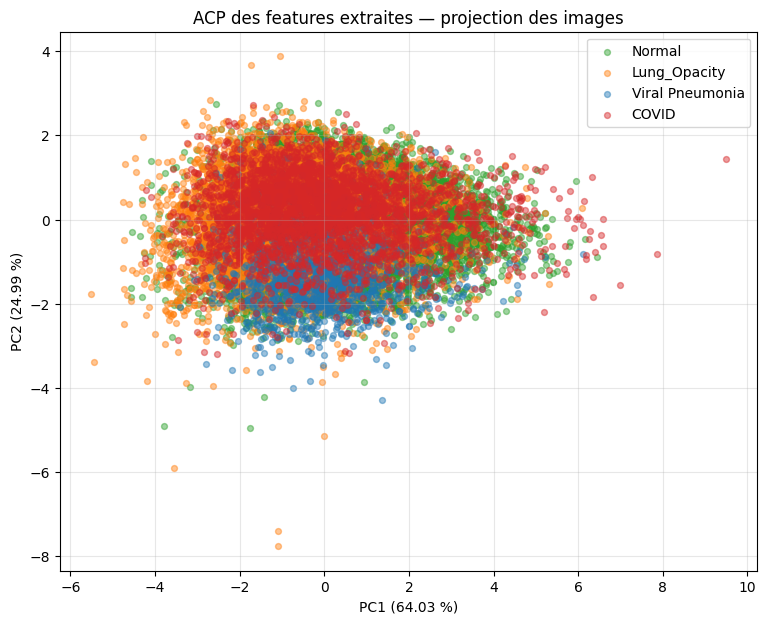

In [38]:
# ¨Projection des individus

colors = {
    "COVID": "#d62728",
    "Normal": "#2ca02c",
    "Lung_Opacity": "#ff7f0e",
    "Viral Pneumonia": "#1f77b4"
}

classes = ["Normal", "Lung_Opacity", "Viral Pneumonia", "COVID"]

plt.figure(figsize=(9, 7))

for class_name in classes:
    subset = df_pca[df_pca["classe"] == class_name]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=class_name,
        color=colors[class_name],
        alpha=0.45,
        s=18
    )

plt.title("ACP des features extraites — projection des images")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f} %)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f} %)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

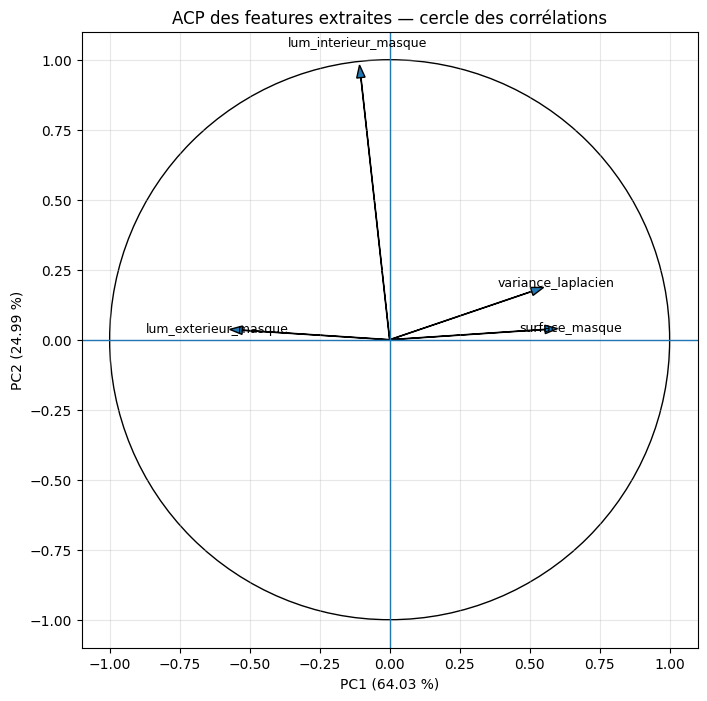

In [39]:
# vecteurs des variables

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features_cols
)

plt.figure(figsize=(8, 8))

# Cercle des corrélations
circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_artist(circle)

for feature in features_cols:
    x = loadings.loc[feature, "PC1"]
    y_var = loadings.loc[feature, "PC2"]

    plt.arrow(
        0, 0,
        x, y_var,
        head_width=0.03,
        length_includes_head=True
    )

    plt.text(
        x * 1.08,
        y_var * 1.08,
        feature,
        ha="center",
        va="center",
        fontsize=9
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f} %)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f} %)")

plt.title("ACP des features extraites — cercle des corrélations")
plt.grid(alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

## Heatmap des corrélations

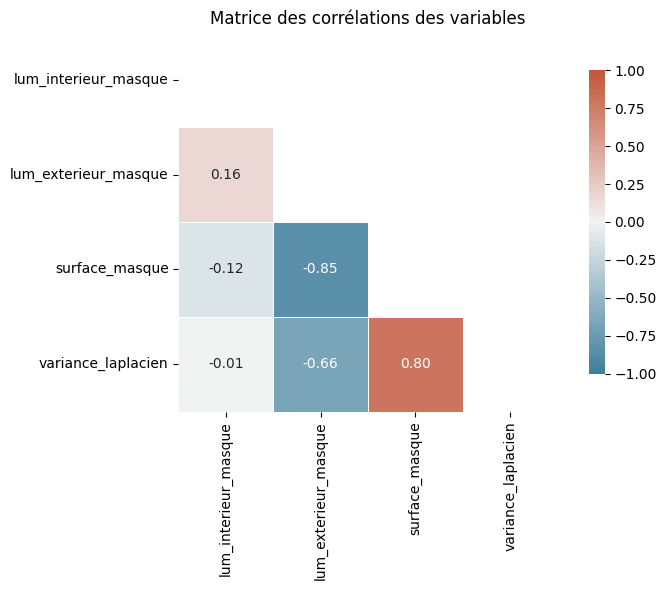

In [40]:
# Variables numériques
features_cols = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

# Matrice de corrélations
corr = df_all_features[features_cols].corr()

# Masque pour masquer la moitié supérieure
mask = np.triu(np.ones_like(corr, dtype=bool))

# Figure
plt.figure(figsize=(8,6))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink":0.8}
)

plt.title("Matrice des corrélations des variables")
plt.tight_layout()
plt.show()